# Homework 1

This file contains the solutions to the computational problems in Homework 2 from MATH 5750 taught by Braxton Osting during the Fall 2026 semester.

This code is a mix between my own work, reference code released by Braxton Osting, and code generated by ChatGPT.

Import packages and first 10,000 images from dataset, scaling them to [0,1].

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
SEED = 0
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X = X[:10000].astype(float) / 255.0
y = y[:10000].astype(int)

In [2]:
from pathlib import Path

import pandas as pd
from scipy.sparse.csgraph import shortest_path
from sklearn.datasets import (
    fetch_olivetti_faces,
    load_digits,
    load_iris,
    make_swiss_roll,
)
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


In [3]:
print("Shape of data array:", X.shape)
counts = np.bincount(y, minlength=10)
for digit in range(10):
    print(f"Digit {digit}: {counts[digit]} images")

Shape of data array: (10000, 784)
Digit 0: 1001 images
Digit 1: 1127 images
Digit 2: 991 images
Digit 3: 1032 images
Digit 4: 980 images
Digit 5: 863 images
Digit 6: 1014 images
Digit 7: 1070 images
Digit 8: 944 images
Digit 9: 978 images


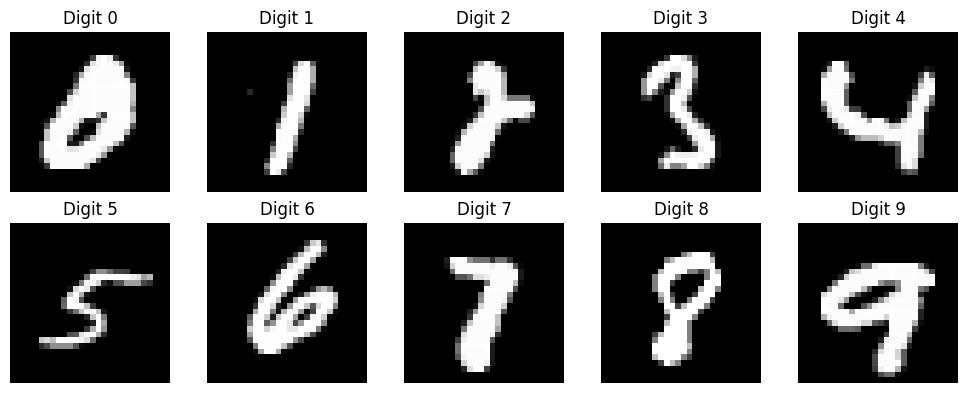

In [4]:
rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in enumerate(axes.flat):
    possible_indices = np.where(y == digit)[0]
    index = rng.choice(possible_indices)

    ax.imshow(X[index].reshape(28, 28), cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Now we will fit PCA to the data.

In [5]:
pca = PCA(random_state=SEED)
pca.fit(X)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

levels = [0.90, 0.95, 0.99]

for level in levels:
    k = np.searchsorted(cumulative, level) + 1
    compression_factor = 784 / k
    print(f"{int(level*100)}% variance: k = {k}, compression factor = {compression_factor:.2f}")

90% variance: k = 85, compression factor = 9.22
95% variance: k = 150, compression factor = 5.23
99% variance: k = 326, compression factor = 2.40


Make plots that are required in the homework assignment.

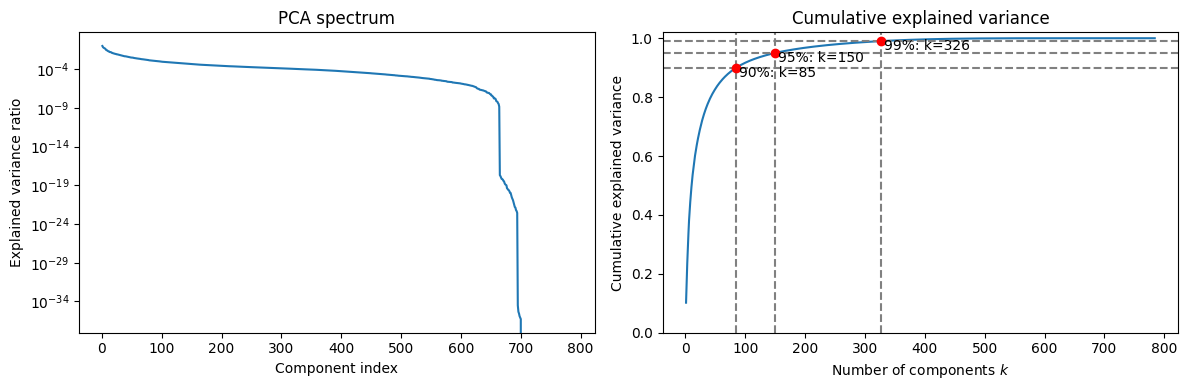

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: explained variance ratio, logarithmic vertical axis
axes[0].semilogy(
    np.arange(1, len(explained) + 1),
    explained
)
axes[0].set_xlabel("Component index")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("PCA spectrum")

# Right: cumulative variance
axes[1].plot(
    np.arange(1, len(cumulative) + 1),
    cumulative
)

for level in levels:
    k = np.searchsorted(cumulative, level) + 1

    axes[1].axhline(level, color="gray", linestyle="--")
    axes[1].axvline(k, color="gray", linestyle="--")
    axes[1].plot(k, cumulative[k - 1], "ro")
    axes[1].text(k + 5, level - 0.03, f"{int(level*100)}%: k={k}")

axes[1].set_xlabel("Number of components $k$")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance")
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

Now we will analyze what PCA is doing on a step by step basis to reconstruct images.

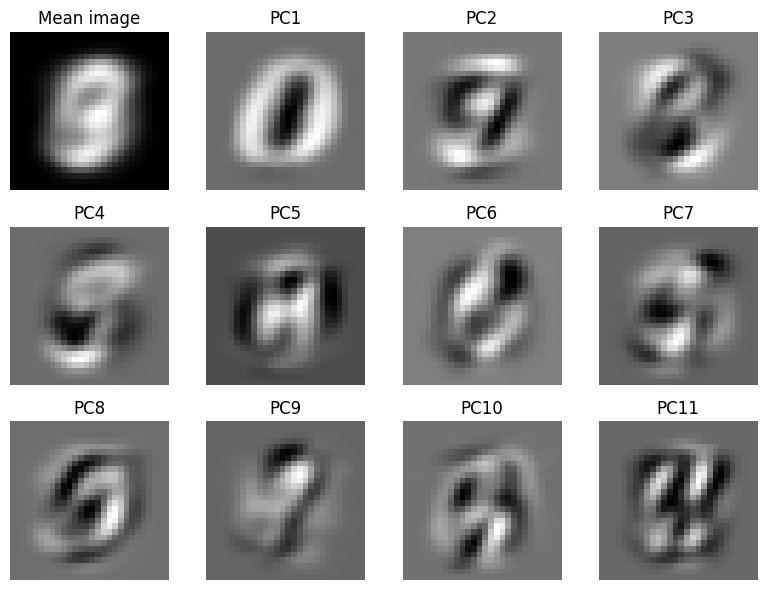

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(8, 6))

# Mean image
axes.flat[0].imshow(pca.mean_.reshape(28, 28), cmap="gray")
axes.flat[0].set_title("Mean image")
axes.flat[0].axis("off")

# PC1 through PC11
for j in range(11):
    axes.flat[j + 1].imshow(
        pca.components_[j].reshape(28, 28),
        cmap="gray"
    )
    axes.flat[j + 1].set_title(f"PC{j + 1}")
    axes.flat[j + 1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
k95 = np.searchsorted(cumulative, 0.95) + 1

image_index = 0       # change this to choose a different MNIST image
x_original = X[image_index]

k_values = [1, 5, 10, 25, 50, 100, k95]

reconstructions = []
mean_image = np.mean(X, axis=0)

# Denominator in the relative reconstruction error
denominator = np.linalg.norm(X - mean_image, ord="fro")

for k in k_values:
    pca_k = PCA(n_components=k, random_state=SEED)

    # PCA coordinates ("scores") and reconstructed full dataset
    X_scores = pca_k.fit_transform(X)
    X_reconstructed = pca_k.inverse_transform(X_scores)

    # Reconstruction of the one selected image
    reconstructions.append(X_reconstructed[image_index])

    # Requested statistics
    variance_kept = np.sum(pca_k.explained_variance_ratio_)
    relative_error = np.linalg.norm(
        X - X_reconstructed, ord="fro"
    ) / denominator

    print(
        f"k = {k:3d}: "
        f"variance kept = {variance_kept:.4f}, "
        f"relative reconstruction error = {relative_error:.4f}"
    )

k =   1: variance kept = 0.1020, relative reconstruction error = 0.9476
k =   5: variance kept = 0.3372, relative reconstruction error = 0.8141
k =  10: variance kept = 0.4943, relative reconstruction error = 0.7111
k =  25: variance kept = 0.6974, relative reconstruction error = 0.5500
k =  50: variance kept = 0.8283, relative reconstruction error = 0.4144
k = 100: variance kept = 0.9169, relative reconstruction error = 0.2883
k = 150: variance kept = 0.9500, relative reconstruction error = 0.2235


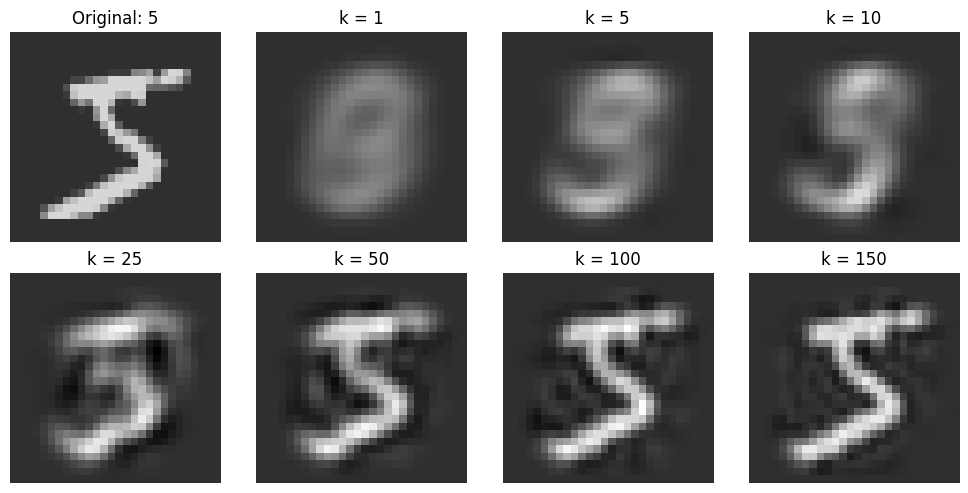

In [9]:
all_images = [x_original] + reconstructions
vmin = min(image.min() for image in all_images)
vmax = max(image.max() for image in all_images)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

axes.flat[0].imshow(
    x_original.reshape(28, 28),
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)
axes.flat[0].set_title(f"Original: {y[image_index]}")
axes.flat[0].axis("off")

for ax, k, x_recon in zip(axes.flat[1:], k_values, reconstructions):
    ax.imshow(
        x_recon.reshape(28, 28),
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"k = {k}")
    ax.axis("off")

plt.tight_layout()
plt.show()